In [1]:
# This notebook is all about why we need trees in ML and how did they even came to existence.

In [2]:
# Import some required libraries 
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

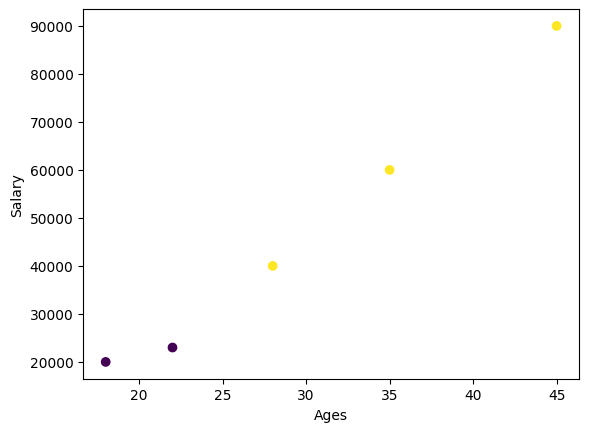

In [3]:
# Suppose we have a dataset  : 
df = pd.DataFrame({
    "age" : [18,22,28,35,45],
    "salary" : [20000,23000,40000,60000,90000],
    "bought" : [0,0,1,1,1] # 1 for yes and 0 for now
})

# Plotting this dataset
plt.scatter(df['age'],df['salary'],c=df['bought'])
plt.xlabel("Ages")
plt.ylabel("Salary")
plt.show()

In [4]:
df

,age,salary,bought
0,18,20000,0
1,22,23000,0
2,28,40000,1
3,35,60000,1
4,45,90000,1


In [5]:
# This above dataset can be easily seperated by a linear classifier model like logisitic regression or 
# polynomial classifier as there is a linear pattern seen here.

# Why easily seperable cause we can draw a single line that would act as a classifier .
# All the points above the line (+ve) are one class and below are another(-ve).

# We can choose rules such as : age = 25 as classifier .
# Points above this age belong to one class and points below this in another class.

In [6]:
# Now look at the below dataset where the patterns are based on decisions and cannot be seperated by linear models.
# No matter how much we rotate the lines or translate it we wont be able to seperate the two classes with just a single line 
# We need to draw more than one line or make multiple decisions to seperate this classes.

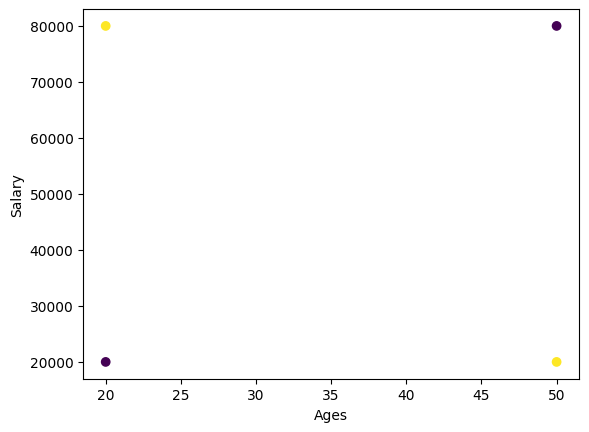

In [7]:
# Suppose we have now this dataset  : 
df = pd.DataFrame({
    "age" : [20,20,50,50],
    "salary" : [20000,80000,20000,80000],
    "bought" : [0,1,1,0] # 1 for yes and 0 for now
})

# Plotting this dataset
plt.scatter(df['age'],df['salary'],c=df['bought'])
plt.xlabel("Ages")
plt.ylabel("Salary")
plt.show()

In [8]:
df

,age,salary,bought
0,20,20000,0
1,20,80000,1
2,50,20000,1
3,50,80000,0


In [9]:
# Actually the prediciton is based on decison or you can say a nested if else statemnt 
# It is like : 
i = 0 # The index # Tweak and we get all the outputs
if df['age'].iloc[i] <30 :
    if df['salary'].iloc[i] < 50000:
        y_hat = 0
    else:
        y_hat = 1
else:
    if df['salary'].iloc[i] < 50000:
        y_hat = 1
    else:
         y_hat = 0

y_hat
# See that we have so many decisions !!!
# Each decision is a split on it's own .

0

In [10]:
# SO instead of solving equations we create splits for points and segregate each points using those rules.
# Why question ? let's look closely what we did : 

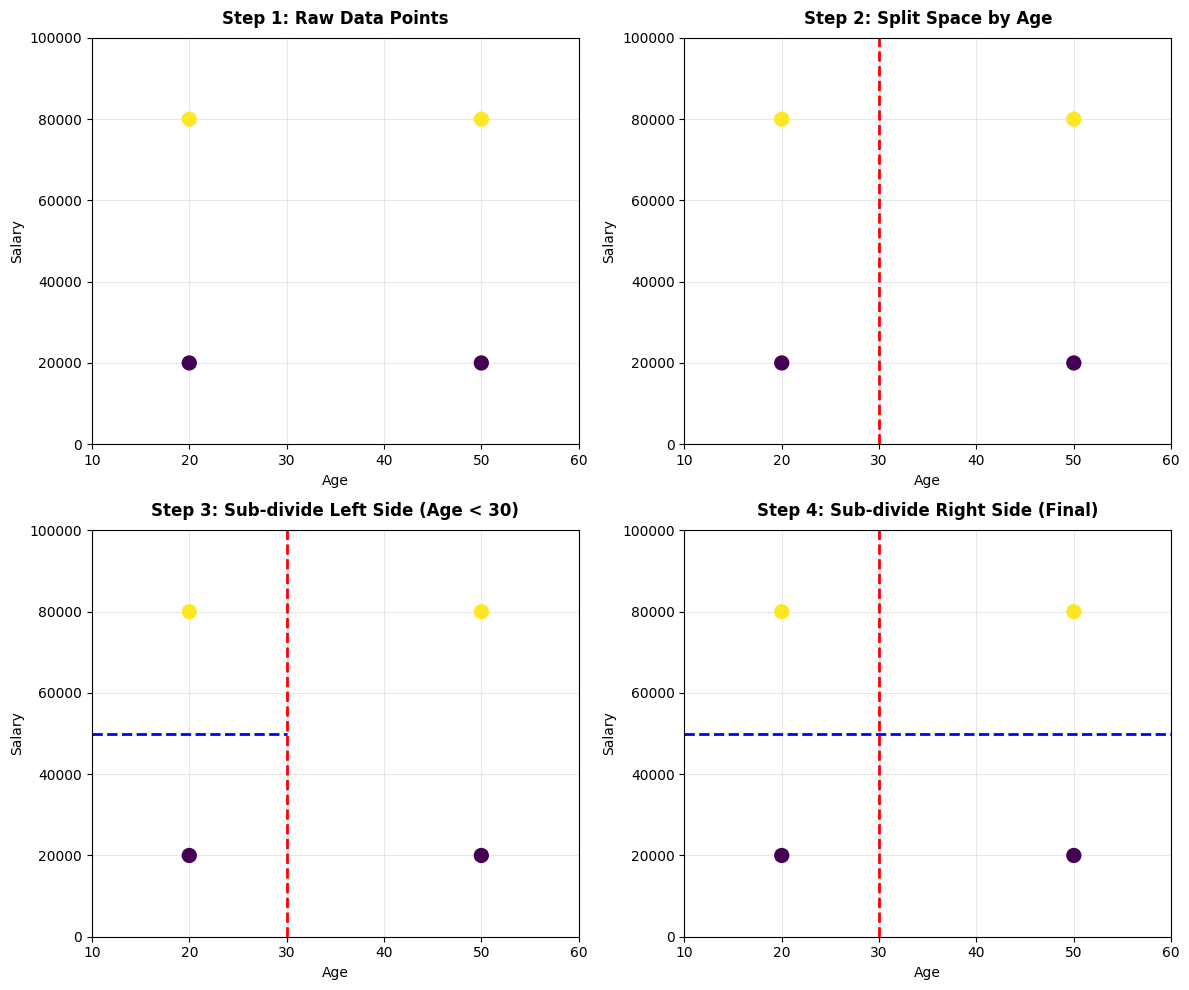

In [11]:
# Remember the above if else statement ? Each statement is actively dividing the graph into different sections 
# Let's look at how the boundaries look in graph : 

# Create a 2x2 grid figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten into a 1D array for easy indexing


# Helper function to apply common styles to each subplot
def format_subplot(ax, title):
    ax.scatter(df["age"], df["salary"], c=df['salary'], s=100, zorder=3)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Age")
    ax.set_ylabel("Salary")
    ax.set_xlim(10, 60)
    ax.set_ylim(0, 100000)
    ax.grid(True, alpha=0.3)


# --- Plot 1: Raw Data ---
format_subplot(axes[0], "Step 1: Raw Data Points")

# --- Plot 2: First Split (Age) ---
format_subplot(axes[1], "Step 2: Split Space by Age")
axes[1].axvline(x=30, color="red", linestyle="--", linewidth=2)

# --- Plot 3: Sub-divide Left Side ---
format_subplot(axes[2], "Step 3: Sub-divide Left Side (Age < 30)")
axes[2].axvline(x=30, color="red", linestyle="--", linewidth=2)
# Line spans from x=10 to x=30 (xmin=0.0 to xmax=0.4 on a 10-60 scale)
axes[2].axhline(
    y=50000, xmin=0.0, xmax=0.4, color="blue", linestyle="--", linewidth=2
)

# --- Plot 4: Sub-divide Right Side ---
format_subplot(axes[3], "Step 4: Sub-divide Right Side (Final)")
axes[3].axvline(x=30, color="red", linestyle="--", linewidth=2)
# Full line spanning both sides
axes[3].axhline(y=50000, color="blue", linestyle="--", linewidth=2)

# Global layout tuning
plt.tight_layout()
plt.show()


In [12]:
# The first split divdes the graph into two parts and each part now contains 1 yes point and 1 no point each
# This means now we have two points in one side and two point in another side.

# We need to further split so that we can classify each point easily .

# So we head to second split which we do with respect to salary column resulting in splitting the left region in again two parts : 
# You can clearly see that the points now can be segregated into 3 parts : 
#1) Top left quadrant    :  Contains One unique point          : Meaning any point here can be classified as that class
#2) Bottom left quadrant :  Contains One unique point          : Meaning any point here can be classified as that class
#3) Right Quadrant       :  Contains One point from each class : Need to be further split

# Why only 50000 as salary condition and why only age as 30 for splitting ~ for now we chose it arbitarily ,
# by glazing the graph but when deriving equations we must set a specific rule that explains us the reason.

# We divided the complete plot in 4 regions based on nested conditions splitting points in groups 
# This resulted in classifying all points.

# If we look closely the final diagram below we can see that no line can actually do this alone but multiple decision and cuts(lines) can do . 
# We simply make decisions ate each stage to split the data into regions then classifying

### Final diagram : 
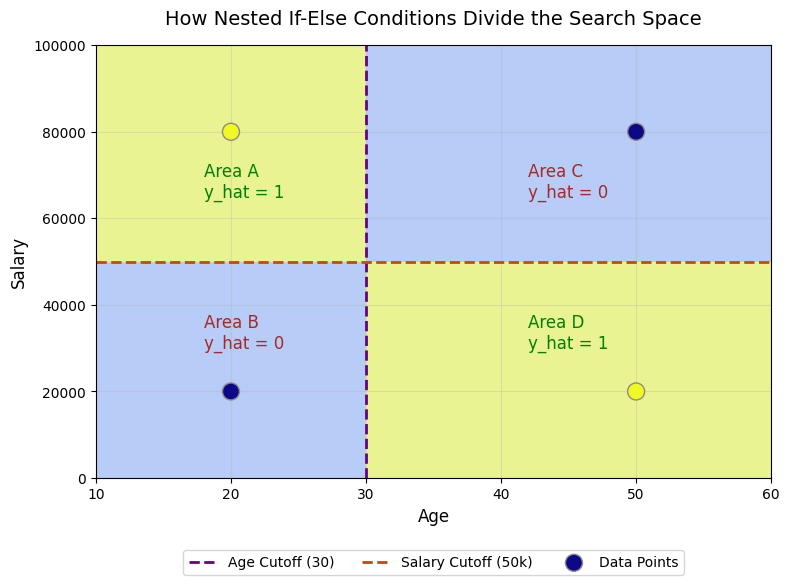

In [13]:
# Another example is : When a person decides to buy a laptop
""" 
                                                Is my budget below 70k?
                                                    ↓
                                                    Yes
                                                    ↓
                                                Need gaming?
                                                    ↓
                                                    Yes
                                                    ↓
                                                RTX laptop
                                                    ↓
                                                    No
                                                    ↓
                                                Thin laptop
"""

' \n                                                Is my budget below 70k?\n                                                    ↓\n                                                    Yes\n                                                    ↓\n                                                Need gaming?\n                                                    ↓\n                                                    Yes\n                                                    ↓\n                                                RTX laptop\n                                                    ↓\n                                                    No\n                                                    ↓\n                                                Thin laptop\n'

In [14]:
# This is literally divide and conquer strategy as we actively split the data into parts and solve the parts further.

In [15]:
# Desired Property ~ For our trees

# Assume the parent is the original slice without splitting and the children is the set/s formed after making a decision.
# A good question should make the children simpler than the parent.


# Imagine Parent : 50 Yes and 50 No
# There is a lot of "Confusion" we can say .
# Now what does confusion mean here in this context is : Uncertanity
# Look closely If we have 50 yes and 50 no then we have the highest amount of uncertanity for any class : Yes or No
# Why ? As both their probability is 1/2 each , so this is the highest amount of  confusion possible let's say 100%.


# After asking : 
#   Age<30? Suppose we get : 

#       Left:   48 No and 2 Yes  : There is 96% chance of No here and 4% chance of Yes.
#       Right:  2 No and 48 Yes  : There is 96% chance of Yes here and 4% chance of No.

# Now each side is much easier ( Has a lot less uncertanity compared to earlier )
# The uncertainty dropped a lot because of the split ( This was the main idea or one way of thinking what we did earlier).

# Everything now boils down to one idea   :   What is a good mathematical definition of "confusion" or "impurity" in a set of labels?

# If we can measure impurity, then we can:

# Measure impurity before a split.
# Measure impurity after a split.
# Choose the split that reduces impurity the most.
# Repeat recursively until the data is sufficiently pure.

# So basically what we can do if we get a numeric value is create numerous cases from each features and use them make decisions and split them.
# Now do that for many numeric values and the one which reduced the confusion the most will be the best split.

## We want some sort of metric which measure confusion   

### parent :
| Person | Age | Bought? |
| ------ | --- | ------- |
| A      | 18  | No      |
| B      | 20  | No      |
| C      | 22  | No      |
| D      | 45  | Yes     |
| E      | 48  | Yes     |
| F      | 52  | Yes     |
--- 
## Split 1 : If we choose age < 30 : 

### child 1 : 
| Person | Age | Bought? |
| ------ | --- | ------- |
| A      | 18  | No      |
| B      | 20  | No      |
| C      | 22  | No      |

### child 2 : 
| Person | Age | Bought? |
| ------ | --- | ------- |
| D      | 45  | Yes     |
| E      | 48  | Yes     |
| F      | 52  | Yes     |

### No confusion in any split both contain pure values of Yes and No
---
## Split 2  : Age < 46 : 

### child 1 : 
| Person | Age | Bought? |
| ------ | --- | ------- |
| A      | 18  | No      |
| B      | 20  | No      |
| C      | 22  | No      |
| D      | 45  | Yes     |

### child 2 : 
| Person | Age | Bought? |
| ------ | --- | ------- |
| E      | 48  | Yes     |
| F      | 52  | Yes     |

### The left split has a bit of confusion as there is a Yes and right split is pure with no confusion
--- 
## Split 3  : Age < 100 : 

### child : 
| Person | Age | Bought |
| ------ | --- | ------- |
| A      | 18  | No      |
| B      | 20  | No      |
| C      | 22  | No      |
| D      | 45  | Yes     |
| E      | 48  | Yes     |
| F      | 52  | Yes     |

### Complete and highest amount of confusion



In [16]:
# But the thing is how to define this confusion , one thing I know is we have to make sure that the confusion value lets say c 
# should be highest for when the probabilities of classes are almos equal or equal and decrease as the probability of a class dominates other

# Another question is should our confusion depend on Probability of the classes present in each split ? Yes tbh absolutely.
# | Person | Age | Bought? |
# | ------ | --- | ------- |
# | A      | 18  | No      |
# | B      | 20  | No      |
# | C      | 22  | No      |
# | D      | 45  | Yes     |

# Assume this the P(Yes) = 1/4 and P(No) = 3/4
# We are not concerned about the numbers here but instead the ratios i.e : 0.25 : 0.75

# One thing we make sure that for binary classification problem now :
# p = P(class 1) and p-1 = P(class 2)
# AS we know from probability theory that Probability must equal to 1.

## Binary Classification Confusion Function
## Setup
Imagine binary classification. Let:

* p = P(Yes)
* 1 - p = P(No)

Our confusion function becomes:
$$\text{Confusion}(p)$$
What should it look like?
------------------------------
## Behavior at Key Points
## 1. If p = 1 
Everyone is Yes.

* Yes
* Yes
* Yes

Confusion should be: 0
## 2. If p = 0
Everyone is No.

* No
* No
* No

Confusion should be: 0
## 3. If p = 0.5
Balanced split.

* Yes
* No
* Yes
* No

Confusion should be: Maximum uncertainty / Maximum confusion.
------------------------------
## The Graph
Our graph should look like this:

Confusion

      |           ▲
      |          / \
      |         /   \         
      |        /     \
      |       /       \
      |      /         \
      |_____/___________\____ p
            0    0.5    1

------------------------------
## Required Properties
Our confusion function must meet these four requirements:

* Be 0 at p = 0
* Be 0 at p = 1
* Reach its maximum at p = 0.5
* Be symmetric, because swapping "Yes" and "No" doesn't change the uncertainty.

------------------------------



In [17]:
# Now Let's hunt for functions that satisfy our required properties for confusion function : 

# Proposal 1  :  Linear Function

# If we use C(p) = p
# This wont work as for a high value of p like 1 the answer is p , but recall for p let's say 1 the function should output 0 (no confusion)

# If we use C(p) = 1-p
# This wont work either suppose we have p = 0 (No values present) gives : C = 1 , which means total confusion ; Absolutely false.


# Proposal 2 :  Quadratic Function (Parabola)
# A parabola with max value at center and 0 at ends.

# Candidate 1  : C(p)=p(1−p)
# Now verifying different values to put in this equation : 

# | (p) | (p(1-p)) |
# | --- | -------- |
# | 0   | 0        |
# | 0.1 | 0.09     |
# | 0.2 | 0.16     |
# | 0.3 | 0.21     |
# | 0.4 | 0.24     |
# | 0.5 | 0.25     |
# | 0.6 | 0.24     |
# | 0.7 | 0.21     |
# | 0.8 | 0.16     |
# | 0.9 | 0.09     |
# | 1   | 0        |


# This satisfies all of the things , we got max value of 0.25 instead of 1 but rest edge cases are gracefully handled.
# So what if we multiply this value with 4 ? Gives : C(p) = 4p(1-p)

# | p   | Confusion |
# | --- | --------- |
# | 0   | 0         |
# | 0.5 | 1         |
# | 1   | 0         |


# BETTER !!!

# Note that the values 4 itself is constant and can be written as : G(p)=2p(1−p) # G is for Gini Impurity ( The name of function we derived )
# For multiclass problems this equation becomes : G = 1 - sum(p_i**2) # P stand for proba for each class

# IF we verify this for the case of Binary classification : pYes​=p,pNo​=1−p
# we get

# G=1−(p^2+(1-p)^2) = 1 - 1 + 2p - 2p**2 = 2p(1−p) # Exactly what we derived.

# What this number measures ? 
# Let's say for : 

# 90% Yes
# 10% No    

# Gini value  : 2(0.9)(0.1)=0.18

# What does that mean ? - Simply says : "This node is more impure than another."

In [18]:
# But wait what if we have another candidate that satisfies the requirement ? Is it also VALID ? yes OFC 
# That is exactly what we are gonna decode now : 

# Now what about we dont deal with confusion itself > What about information ?
# Not also just information - surprise .

# Why surprise ? 

# Suppose I tell you : "The sun will rise tomorrow."
#    Did you learn much? - Not really.
#    You were almost certain already.

#    Now suppose I tell you : "You won the lottery."
#    That message contains a huge amount of information because it was extremely unexpected.

# Conclusion  :  The rarer an event is, the more information you gain when it happen.


""" 
This is why entropy appears
    Gini asks:"How mixed is this node?"
    Shannon asks:"How much information is still missing before I know the class?" 

Both are polar opposites of each other.
"""

' \nThis is why entropy appears\n    Gini asks:"How mixed is this node?"\n    Shannon asks:"How much information is still missing before I know the class?" \n\nBoth are polar opposites of each other.\n'

# The Story of Entropy and Information

This is the story of how Claude Shannon looked at a static-filled telephone wire in 1948 and inadvertently handed machine learning engineers the perfect tool to build decision trees.

Let’s step into his shoes.

---

## Act I: The Million-Dollar Whisper

Imagine you are sitting in Bell Labs. The year is 1948. Telegrams are clicking, radio towers are humming, and everyone is trying to figure out how to squeeze more words through copper wires.

You ask a deceptively simple question: "What is information?"

Engineers tell you it’s the number of letters in a word. You disagree. You realize information isn't about the ink on the page; it's about the shock value to the brain.

You look out the window. Someone says, "The sun will rise tomorrow." You don't even blink. You already knew that. The probability p is 1. Because you expected it completely, that sentence gave you zero information.

Suddenly, your phone rings. A voice says, "You just won a billion dollars." Your heart stops. The probability of that happening was almost zero (p = 0.000001). Because it was incredibly rare, it carries a massive tidal wave of information.

You grab a napkin and write down your first rule:

> **Information is just a measure of surprise.**
> If an event is guaranteed (p=1), surprise is 0. As an event gets rarer (p → 0), surprise explodes toward infinity.

```text
Information (Surprise)
 ^
 | \
 |  \
 |   \
 |    \
 +------>
 0      1  Probability (p)
```

---

## Act II: The Mathematical Marriage

Now, you want to turn this intuition into a strict mathematical formula. You need a function, let's call it $I(p)$, that draws that exact downward slope. But there are infinite curves that slide downward. Which one is correct?

You think about receiving messages.

Suppose you flip a coin behind a curtain. You tell your friend, "It's Heads." That gives them a certain amount of information. Then you flip a second, completely independent coin. You tell them, "This one is also Heads."

Naturally, your friend just received twice the amount of information. The total surprise of two independent events should simply add together:

$$\text{Total Information} = \text{Info(Coin 1)} + \text{Info(Coin 2)}$$

But wait. What happens to the probabilities of independent events? They don't add; they multiply. The chance of flipping two heads in a row is $0.5 \times 0.5 = 0.25$.

You sit back in your chair, amazed by the paradox:
* On the outside, the probabilities are multiplying ($p \times q$).
* On the inside, our brains are adding the information ($I(p) + I(q)$).

You need a mathematical machine that takes multiplication and converts it into addition:

$$I(p \times q) = I(p) + I(q)$$

You smile. There is only one function in the entire universe born to do this: The Logarithm. Because $\log(a \times b) = \log(a) + \log(b)$.

To make sure it slopes downhill (so smaller probabilities give bigger numbers), you throw a negative sign in front of it. You write down the fundamental law of information:

$$I(p) = -\log(p)$$

You test it. If $p=1$, then $-\log(1) = 0$. Zero surprise. It works perfectly.

---

## Act III: From Individual Shock to the "Average Weather"

Now, let's fast-forward and pivot. We leave Shannon's desk and walk into a modern machine learning lab. We are trying to build a decision tree to predict if a customer will buy a product.

We look at a group of people at a specific node in our tree:
* 80% said Yes ($p = 0.8$)
* 20% said No ($p = 0.2$)

We want to measure the information of this entire group. But we run into a roadblock. We can’t just calculate $-\log(0.8)$, because not everyone said Yes. We can’t just calculate $-\log(0.2)$, because not everyone said No.

We need to know the average surprise we will encounter if we pick a random person from this room.

In probability, when you want the average of something weighted by how often it happens, you calculate the **Expected Value**.

You take the probability of the first outcome, multiply it by its surprise, and add it to the probability of the second outcome multiplied by its surprise:

$$\text{Average Surprise} = \Big( P(\text{Yes}) \times \text{Surprise}(\text{Yes}) \Big) + \Big( P(\text{No}) \times \text{Surprise}(\text{No}) \Big)$$

Substituting Shannon's formula ($-\log(p)$) for surprise, you get:

$$H = - \sum p_i \log(p_i)$$

You look at the whiteboard. You have just derived **Entropy**.

---
## Act IV: The Classroom Split (The Weighted Average)

Now, how do we use this entropy to evaluate a split? This is where subset proportions (weights) come into play. Imagine you have a Parent Node containing a school class of 10 students. You decide to split them into two child nodes based on a specific study habit.

### 1. Slicing the Class (Determining the Weights)

Your split rule divides the 10 students unevenly:
* **Group A (Child 1):** Attracted 8 students. Its proportional weight is $w_A = \frac{8}{10} = 0.8$ (It accounts for 80% of the data).
* **Group B (Child 2):** Attracted 2 students. Its proportional weight is $w_B = \frac{2}{10} = 0.2$ (It accounts for 20% of the data).

### 2. Measuring Chaos in the Children (Calculating Entropy)

Next, we calculate the independent entropy ($H$) for each child node based on how many students passed:
* **Group A:** Pure and orderly. Almost everyone passed. Its entropy is very low: $H_A = 0.10$.
* **Group B:** Complete chaos. A perfect 50/50 mix of passes and fails. Its entropy is at maximum: $H_B = 1.00$.

### 3. Squeezing it Together (The Weighted Average)

To find the final score of this split, we cannot just calculate a standard average:

$$\frac{0.10 + 1.00}{2} = 0.55$$

That would falsely imply that the tiny, chaotic Group B is just as important as the massive, orderly Group A. Instead, we multiply each child's entropy by its proportional weight using the conditional entropy formula:

$$\text{Conditional Entropy} = (w_A \times H_A) + (w_B \times H_B)$$

$$\text{Conditional Entropy} = (0.8 \times 0.10) + (0.2 \times 1.00)$$

$$\text{Conditional Entropy} = 0.08 + 0.20 = 0.28$$

Because Group A held 80% of the classroom, its low entropy heavily pulled down the final score to 0.28, proving that this split successfully organized the vast majority of the data.


In [19]:
# 1. Create the structured intuition dataset
data = {
    'Sample_ID': [1, 2, 3, 4],
    'Feature_X': [1, 1, 0, 0],
    'Target_Y':  [1, 1, 1, 0]
}
df = pd.DataFrame(data)
print("--- Initial Dataset ---")
print(df.to_string(index=False))
print("\n" + "="*50 + "\n")

# 2. Define Traditional Logarithmic Entropy 
def calculate_entropy(series):
    if len(series) == 0:
        return 0.0
    p1 = sum(series == 1) / len(series)
    p0 = 1 - p1
    entropy = 0.0
    if p1 > 0: entropy -= p1 * np.log2(p1)
    if p0 > 0: entropy -= p0 * np.log2(p0)
    return entropy

# 3. Define Gini Impurity (Your alternate 2p(1-p) formula)
def calculate_gini(series):
    if len(series) == 0:
        return 0.0
    p1 = sum(series == 1) / len(series)
    return 2 * p1 * (1 - p1)

# 4. Separate dataset based on Feature X split
total_samples = len(df)
target_parent = df['Target_Y']
target_x1 = df[df['Feature_X'] == 1]['Target_Y']
target_x0 = df[df['Feature_X'] == 0]['Target_Y']

# Split Weights
w_x1 = len(target_x1) / total_samples
w_x0 = len(target_x0) / total_samples

# 5. Process Traditional Information Gain
ent_parent = calculate_entropy(target_parent)
ent_x1 = calculate_entropy(target_x1)
ent_x0 = calculate_entropy(target_x0)
cond_entropy = (w_x1 * ent_x1) + (w_x0 * ent_x0)
info_gain = ent_parent - cond_entropy

# 6. Process Gini Gain 
gini_parent = calculate_gini(target_parent)
gini_x1 = calculate_gini(target_x1)
gini_x0 = calculate_gini(target_x0)
cond_gini = (w_x1 * gini_x1) + (w_x0 * gini_x0)
gini_gain = gini_parent - cond_gini

# 7. Print Results
print("METHOD 1: TRADITIONAL ENTROPY (ID3/C4.5)")
print(f"  Parent EntropyH(Y)   :   {ent_parent:.4f}")
print(f"Subset Entropy H(Y|X=1):   {ent_x1:.4f}")
print(f"Subset Entropy H(Y|X=0):   {ent_x0:.4f}")
print(f"   Information Gain    :   {info_gain:.4f}\n")

print("METHOD 2: GINI IMPURITY (CART)")
print(f"Parent Gini Impurity:      {gini_parent:.4f}")
print(f"Subset Gini G(Y|X=1):      {gini_x1:.4f}")
print(f"Subset Gini G(Y|X=0):      {gini_x0:.4f}")
print(f"  Gini Gain (Delta) :      {gini_gain:.4f}")


--- Initial Dataset ---
 Sample_ID  Feature_X  Target_Y
         1          1         1
         2          1         1
         3          0         1
         4          0         0


METHOD 1: TRADITIONAL ENTROPY (ID3/C4.5)
  Parent EntropyH(Y)   :   0.8113
Subset Entropy H(Y|X=1):   0.0000
Subset Entropy H(Y|X=0):   1.0000
   Information Gain    :   0.3113

METHOD 2: GINI IMPURITY (CART)
Parent Gini Impurity:      0.3750
Subset Gini G(Y|X=1):      0.0000
Subset Gini G(Y|X=0):      0.5000
  Gini Gain (Delta) :      0.1250


In [ ]:
# Now let's generalize both these formulae as in real world there is a high probability that the classification problem we are dealing with is having: 
# n-Classes where n can be any integer : 2,3,4...n

# Now what we used to do earlier was we used to have 2 classes so we only had p and 1-p.
# Given we had p value we could have also calculated the probability of other class.

# But now imagine this : 
# | Height | Animal |
# | ------ | ------ |
# | 15     | Cat    |
# | 18     | Cat    |
# | 25     | Dog    |
# | 28     | Dog    |
# | 35     | Rabbit |
# | 40     | Rabbit |

# Here we have three classes : Cat , Dog , and Rabbit.
# We have p_cat , p_dog and p_rabbit instead (Our p and 1-p) formulae fails here and we cannot calculate the imurity).

# In such a event there are two independent events that we have to do .
# First is guess what the next animal is going to be and the next is to actual picking up an animal from this dataset.
# As these two events are independent of each other we can multiply these events which are basically the probabilities of each class for each animal.

# So basically the prediction for all guesses and prediction to be correct is : sum(p_i**2)
# And wrong guess is  : 1- sum(p_i**2) as usual
# NOTE : Here i is the sequence till n which is the number of total classes : 

# So our formula now becomes : 1−∑pi**2​ ; this gives us the probability of wrong guesses or confusion.


# And in the cases of Cross Entropy we were actually using the formulae : H=−∑pi.log(pi) 
# Here the p values for binary classification were : p for class 1 and 1-p for class 2 , leading to formulae : 
#       H=−plogp−(1−p)log(1−p)

# As for classification we still have the same mentality : 
# We value the median of such a boundary which shows class transitioning from rows

In [3]:
### Now we move on with Decision Tree Regressors where we make predictions on continous values instead of classes.

In [ ]:
# Now our problem looks like : 
# | House Size (sq ft) | Price ($k) |
# | ------------------ | ---------- |
# | 800                | 120        |
# | 1000               | 150        |
# | 1200               | 180        |
# | 1500               | 240        |
# | 1800               | 300        |

# Now if you look at each value we will find out that each price is unique and will be unique as suppose : 120 and 120.000001 are completely different.
# This means the gini impurity , entropy and information gain all fail for regresion tasks.


# Building a Regression Tree: A Structured First-Principles Example

This document provides a clean, step-by-step walkthrough of how a regression tree operates mechanically. It illustrates how the algorithm transitions from a single baseline prediction to accurate, localized predictions by grouping similar numbers together.

---

## 1. The Dataset

We begin with a simple dataset containing one continuous feature (X = Size) and one continuous target variable (y = Price). 

| House ID | Size (sq ft) | Price (\$k) [y] |
| :---: | :---: | :---: |
| #1 | 800 | 120 |
| #2 | 900 | 130 |
| #3 | 1000 | 140 |
| #4 | 1600 | 280 |
| #5 | 1700 | 290 |
| #6 | 1800 | 300 |

---

## 2. Scenario A: No Split (Single Root Node)

If the algorithm stops immediately and creates no branches, all data points remain trapped inside a single leaf. 

### 2.1 Calculating the Optimal Prediction (ȳ)
To make a single constant prediction for the entire node, the algorithm must find the value that minimizes the **Sum of Squared Errors (SSE)**. Calculus proves that this value is always the mathematical **mean** (ȳ) of the targets:

ȳ = (120 + 130 + 140 + 280 + 290 + 300) / 6 = 1260 / 6 = 210

### 2.2 Quantifying Node Impurity (Variance)
To understand why this single prediction is poor, we measure the "impurity" or numerical spread of this node using its variance (σ²_parent). High variance means the numbers are spread out, meaning a single constant cannot accurately represent them all:

σ²_parent = (1 / N) * Σ (y_i - ȳ)²

σ²_parent = [(120-210)² + (130-210)² + (140-210)² + (280-210)² + (290-210)² + (300-210)²] / 6

σ²_parent = [(-90)² + (-80)² + (-70)² + (70)² + (80)² + (90)²] / 6

σ²_parent = (8100 + 6400 + 4900 + 4900 + 6400 + 8100) / 6 = 38800 / 6 ≈ 6466.67

*   **The Problem:** A variance of **6466.67** is massive. Every house gets a flat prediction of **\$210k**, heavily overestimating the small houses and heavily underestimating the large houses. The model struggles because it forces a single constant to explain two completely different groups of data.

---

## 3. Scenario B: The Optimal Split

To fix this high variance, the algorithm evaluates possible thresholds to find a rule that separates the data into the most internally consistent clusters. It selects the splitting rule: **Size < 1300**.

```text
               [ Size < 1300? ]
                 /          \
               Yes           No
               /              \
        [Left Child]     [Right Child]
```

### 3.1 Left Child Node (Size < 1300)
This node isolates the small, lower-priced houses. Because the numbers are tightly clustered, the new localized prediction becomes highly accurate.

*   **Data Content:** Houses #1, #2, and #3.
*   **Target Values (y_L):** {120, 130, 140}
*   **Leaf Prediction (ȳ_L):** Localized mean.
    ȳ_L = (120 + 130 + 140) / 3 = 130
*   **Node Variance (σ²_L):**
    σ²_L = [(120-130)² + (130-130)² + (140-130)²] / 3 = (100 + 0 + 100) / 3 ≈ 66.67

### 3.2 Right Child Node (Size ≥ 1300)
This node isolates the large, higher-priced houses. Just like the left child, creating a dedicated local prediction removes the massive errors introduced by the small houses.

*   **Data Content:** Houses #4, #5, and #6.
*   **Target Values (y_R):** {280, 290, 300}
*   **Leaf Prediction (ȳ_R):** Localized mean.
    ȳ_R = (280 + 290 + 300) / 3 = 290
*   **Node Variance (σ²_R):**
    σ²_R = [(280-290)² + (290-290)² + (300-290)²] / 3 = (100 + 0 + 100) / 3 ≈ 66.67

### 3.3 Evaluating the Quality of the Split
To prove this split works, we calculate the combined variance remaining in the children, weighted by the number of samples in each node:

σ²_split = (3 / 6) * 66.67 + (3 / 6) * 66.67 = 33.33 + 33.33 = 66.67

By subtracting this from our parent variance, we find the **Variance Reduction** (the regression version of Information Gain):

Δσ² = σ²_parent - σ²_split = 6466.67 - 66.67 = 6400.00

The data became significantly cleaner, dropping the internal error variance from thousands down to a mere 66.67.

---

## 4. Structural Comparison: Classification vs. Regression

This example highlights that the core tree architecture never actually changes; we simply swap out the objective math to match the type of target data.

| Attribute | Classification Tree | Regression Tree (This Example) |
| :--- | :--- | :--- |
| **Target Type** | Categorical classes (e.g., Yes / No) | Continuous numbers (e.g., Price) |
| **Philosophy** | Make class labels as identical as possible | Make numerical values as close as possible |
| **Leaf Output** | **Majority Vote** (Mode of the node) | **Localized Average** (Mean of the node) |
| **Evaluation Metric** | Entropy or Gini Impurity | Variance or Mean Squared Error (MSE) |
| **Splitting Mechanism** | Maximizing **Information Gain** | Maximizing **Variance Reduction** |


In [ ]:
# Now we look at which metric to even use as for similarity ? 
# Like how should we even define that the cluster has similar values ?

# We need a function that can measuere the spread of the points in a leaf let's say : Spread(D)
# It should have the property : 

# Small value → numbers are similar
# Large value → numbers are scattered

# For example 

# Imagine two leaves.

# Leaf A
#   120
#   121
#   119
#   122
#   118

# Everything is tightly packed.Intuitively, this is an excellent leaf.

# Leaf B
#   120
#   210
#   330
#   150
#   280

# Values are scattered everywhere.This is a terrible leaf.


# Now what are the requiremnt for the function ?
# Let's define : 

#   Zero Variance Minimum:      If all target values are identical, the spread must equal 0.
#   Monotonic Distance Scaling: As values move further apart, the spread metric must increase.
#   Directional Invariance:     Positive and negative deviations must be treated equally (ordering does not matter).
#   Mean-Centered Baseline:     Distance must be measured relative to the node's mean (y_bar)), as it mathematically minimizes total squared error.

# The current most ideal function satisfying this is : ∑(yi​−yˉ​)2 (SSE)
# It answers : "How much total disagreement exists inside this leaf?"

# ## Split Evaluation Criteria

# * Variance Reduction Goal: A split is judged by how much it reduces the total Sum of Squared Errors (SSE) across the resulting nodes.
# * Pre-Split State: Mixing distinct clusters creates a high global mean, leading to a massive initial SSE.
# * Post-Split State: Grouping similar values into separate left and right child nodes creates tight local means,drastically lowering the individual SSEs.
# * Analogy to Classification: Minimizing SSE in regression operates identically to minimizing entropy (Information Gain) in classification trees.

# ## Visualized Split Example

#             [ 120, 130, 140, 280, 290, 300 ]  (Mean: 210 | Huge SSE)
#                            / \
#                           /   \
#                          /     \
#                         /       \
#   [ 120, 130, 140 ]                       [ 280, 290, 300 ]
# (Mean: 130 | Tiny SSE)                  (Mean: 290 | Tiny SSE)


## The Regression Tree Objective

* Optimization Goal: Choose the split that achieves the smallest combined Total Sum of Squared Errors **SSE**<sub>left</sub> + **SSE**<sub>right</sub>
 across the child nodes.
* Alternative Formulation: This is mathematically equivalent to minimizing the weighted variance of the child nodes based on their sample sizes.
* Structural Parallel: The underlying architecture of Decision Trees remains identical between classification and regression; only the metric for "impurity" changes:
* Classification: Optimizes for the reduction of uncertainty (e.g., Gini Impurity, Entropy).
   * Regression: Optimizes for the reduction of spread (e.g., Variance, SSE).

## Structural Equivalence Matrix

| Step | Classification Trees | Regression Trees |
|---|---|---|
| Step 1 | Parent Uncertainty | Parent Spread |
| Step 2 | Split Evaluation | Split Evaluation |
| Step 3 | Child Uncertainty | Child Spread |
| Objective | Maximize Entropy Reduction | Maximize Variance Reduction |


In [6]:
# But this leads to a problem ahead that is  : 

When you grow a decision tree without any rules, you are forcing it to split until it cannot split anymore. Structurally, mathematically, and practically, this creates a model that is completely broken for real-world use.
Here is the deeper, broader breakdown of exactly what is happening under the hood.
## 1. Structurally: The Flowchart of Isolation
Every time a decision tree splits, it slices your data space into smaller boxes. If you do not stop it, the tree will keep slicing until every single box contains exactly one data point.

* The Architecture: Your tree becomes incredibly deep and wide. If you have 1,000 rows in your dataset, you will end up with 1,000 unique leaf nodes at the bottom of the tree.
* The "Mean" Illusion: Decision tree leaves predict the average (mean) of the samples inside them. But if Leaf #55 only contains Row #55, the "average" of that single row is just that row's exact value.
* The Isolation: The tree has not grouped similar data together. Instead, it has built a hyper-specific, custom path of if/else rules designed to isolate every single individual row from the rest of the universe.

## 2. Mathematically: The Deception of Zero Error
The mathematical engine driving the tree is the Sum of Squared Errors (SSE). The algorithm's only goal is to make this number as small as possible.

* The Calculation: The formula looks at the gap between reality and prediction: $(y - \hat{y})^2$.
* The Math: If a house in your training data actually costs $300k, and its isolated leaf predicts exactly $300k, the calculation is $(300 - 300)^2 = 0$.
* The Total Sum: When you add up these zeros across all 1,000 rows, your total SSE becomes exactly 0.
* The Flaw: The algorithm "thinks" it has achieved absolute perfection. In reality, it has optimized itself so perfectly to the training data that it has lost all ability to be flexible.

## 3. Practically: Why It Fails on New Data (The Analogy)
Think of this like an overzealous security guard memorizing the exact faces, heights, and outfits of the 50 people who work in an office building today.

* The Lookup Table: The guard doesn't learn the concept of an "employee ID badge" or "company uniform." They just memorize: "John is 6 feet tall, has brown hair, and is wearing a blue shirt."
* The Failure: Tomorrow, John comes to work wearing a green shirt. Because the guard's mental flowchart is hyper-specific to yesterday's outfits, the guard blocks John at the door.
* High Variance: This is what happens to your model. If a new data point is even slightly different from what the tree memorized, the rigid structural paths will route that new data point into a completely wrong leaf, leading to massive, erratic prediction errors.

------------------------------



